# Week 8: Classificatiemodellen in Machine Learning

## Bibliotheken importeren

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn import metrics
import matplotlib.pyplot as plt

## Data inlezen en kolommen selecteren

In [7]:
df = pd.read_csv("titanic.csv", sep=';')
df

,PassengerId,Pclass,Name,Sex,SibSp,Parch,Ticket,Fare,Cabin,Embarked,...,Age,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20
0,1,3,Braund; Mr. Owen Harris,male,1,0,A/5 21171,7.25,NaN,S,...,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,1,Cumings; Mrs. John Bradley (Florence Briggs Th...,female,1,0,PC 17599,712.833,C85,C,...,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,3,Heikkinen; Miss. Laina,female,0,0,STON/O2. 3101282,7.925,NaN,S,...,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,1,Futrelle; Mrs. Jacques Heath (Lily May Peel),female,1,0,113803,53.1,C123,S,...,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,3,Allen; Mr. William Henry,male,0,0,373450,8.05,NaN,S,...,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,2,Montvila; Rev. Juozas,male,0,0,211536,13,NaN,S,...,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
887,888,1,Graham; Miss. Margaret Edith,female,0,0,112053,30,B42,S,...,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
888,889,3,"Johnston; Miss. Catherine Helen ""Carrie""",female,1,2,W./C. 6607,23.45,NaN,S,...,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
889,890,1,Behr; Mr. Karl Howell,male,0,0,111369,30,C148,C,...,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df = df.loc[:, ['Pclass', 'Sex', 'Age', 'Survived']]
df

,Pclass,Sex,Age,Survived
0,3,male,22,0
1,1,female,38,1
2,3,female,26,1
3,1,female,35,1
4,3,male,35,0
...,...,...,...,...
886,2,male,27,0
887,1,female,19,1
888,3,female,15,0
889,1,male,26,1


## One-hot encoding van onafhankelijke niet-numerieke variabelen

In [9]:
df['Pclass'] = df['Pclass'].astype(str)
df.dtypes

Pclass      object
Sex         object
Age          int64
Survived     int64
dtype: object

In [10]:
dummies_dataframe = pd.get_dummies(df.loc[:, ['Sex', 'Pclass']])
dummies_dataframe

,Sex_female,Sex_male,Pclass_1,Pclass_2,Pclass_3
0,False,True,False,False,True
1,True,False,True,False,False
2,True,False,False,False,True
3,True,False,True,False,False
4,False,True,False,False,True
...,...,...,...,...,...
886,False,True,False,True,False
887,True,False,True,False,False
888,True,False,False,False,True
889,False,True,True,False,False


In [11]:
df = pd.concat([df, dummies_dataframe], axis = 1)
df = df.drop(['Sex'], axis = 1)
df = df.loc[df['Age'].notna(), ['Pclass_1', 'Pclass_2', 'Pclass_3', 'Sex_female', 'Sex_male', 'Age', 'Survived']]
df

,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male,Age,Survived
0,False,False,True,False,True,22,0
1,True,False,False,True,False,38,1
2,False,False,True,True,False,26,1
3,True,False,False,True,False,35,1
4,False,False,True,False,True,35,0
...,...,...,...,...,...,...,...
886,False,True,False,False,True,27,0
887,True,False,False,True,False,19,1
888,False,False,True,True,False,15,0
889,True,False,False,False,True,26,1


## Horizontaal en verticaal snijden

In [12]:
X = df.drop('Survived', axis = 1)
y = df.loc[:, ['Survived']]
X

,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male,Age
0,False,False,True,False,True,22
1,True,False,False,True,False,38
2,False,False,True,True,False,26
3,True,False,False,True,False,35
4,False,False,True,False,True,35
...,...,...,...,...,...,...
886,False,True,False,False,True,27
887,True,False,False,True,False,19
888,False,False,True,True,False,15
889,True,False,False,False,True,26


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.15,
    random_state=42
)

In [14]:
list(X.columns)

['Pclass_1', 'Pclass_2', 'Pclass_3', 'Sex_female', 'Sex_male', 'Age']

## Decision Tree bouwen en evalueren

### Max_depth = 2

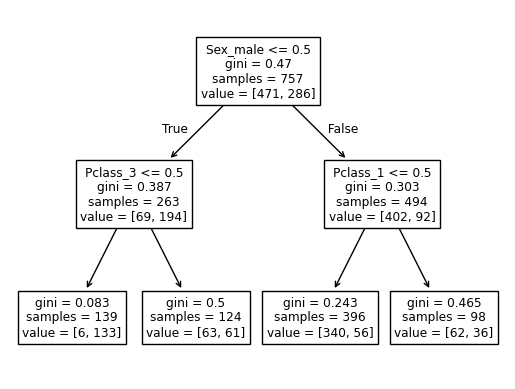

In [15]:
dtree = DecisionTreeClassifier(max_depth = 2)
dtree = dtree.fit(X_train, y_train)
tree.plot_tree(dtree, feature_names = X.columns)
plt.show()

In [16]:
predicted_df = pd.DataFrame(dtree.predict(X_test))
predicted_df = predicted_df.rename(columns = {0 : 'Predicted_Survived'})
model_results_frame = pd.concat([y_test.reset_index()['Survived'], predicted_df], axis = 1)
model_results_frame

,Survived,Predicted_Survived
0,1,0
1,0,0
2,0,0
3,1,1
4,1,0
...,...,...
129,0,0
130,1,0
131,1,0
132,0,0


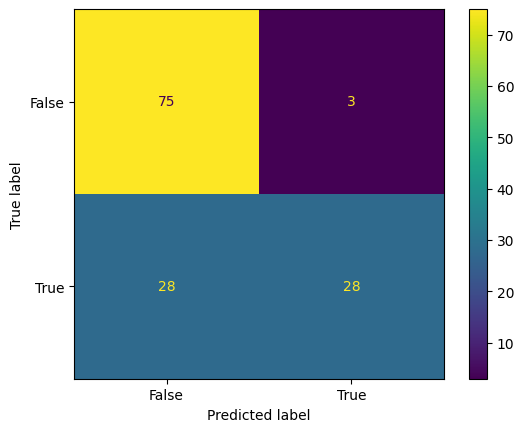

In [17]:
confusion_matrix = metrics.confusion_matrix(model_results_frame['Survived'], model_results_frame['Predicted_Survived'])
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])

cm_display.plot()
plt.show()

In [18]:
metrics.accuracy_score(model_results_frame['Survived'], model_results_frame['Predicted_Survived'])

0.7686567164179104

### Max_depth = 3

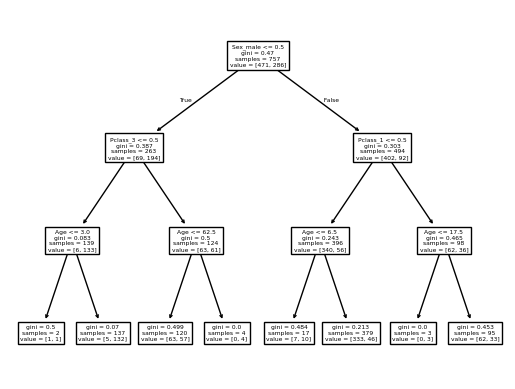

In [19]:
dtree = DecisionTreeClassifier(max_depth = 3)
dtree = dtree.fit(X_train, y_train)
tree.plot_tree(dtree, feature_names = X.columns)
plt.show()

In [20]:
predicted_df = pd.DataFrame(dtree.predict(X_test))
predicted_df = predicted_df.rename(columns = {0 : 'Predicted_Survived'})
model_results_frame = pd.concat([y_test.reset_index()['Survived'], predicted_df], axis = 1)
model_results_frame

,Survived,Predicted_Survived
0,1,0
1,0,0
2,0,0
3,1,1
4,1,0
...,...,...
129,0,0
130,1,0
131,1,0
132,0,0


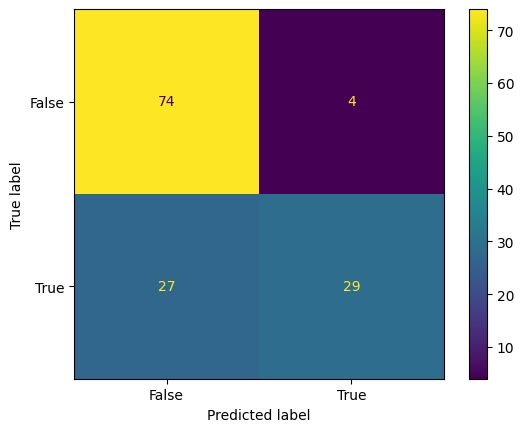

In [21]:
confusion_matrix = metrics.confusion_matrix(model_results_frame['Survived'], model_results_frame['Predicted_Survived'])
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])

cm_display.plot()
plt.show()

In [22]:
metrics.accuracy_score(model_results_frame['Survived'], model_results_frame['Predicted_Survived'])

0.7686567164179104

### Geen Max_depth

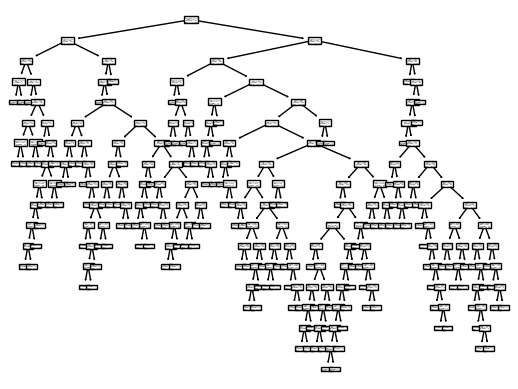

In [23]:
dtree = DecisionTreeClassifier()
dtree = dtree.fit(X_train, y_train)
tree.plot_tree(dtree, feature_names = X.columns)
plt.show()

## Evalueren

In [24]:
predicted_df = pd.DataFrame(dtree.predict(X_test))
predicted_df = predicted_df.rename(columns = {0 : 'Predicted_Survived'})
model_results_frame = pd.concat([y_test.reset_index()['Survived'], predicted_df], axis = 1)
model_results_frame

,Survived,Predicted_Survived
0,1,1
1,0,0
2,0,0
3,1,1
4,1,1
...,...,...
129,0,0
130,1,1
131,1,0
132,0,0


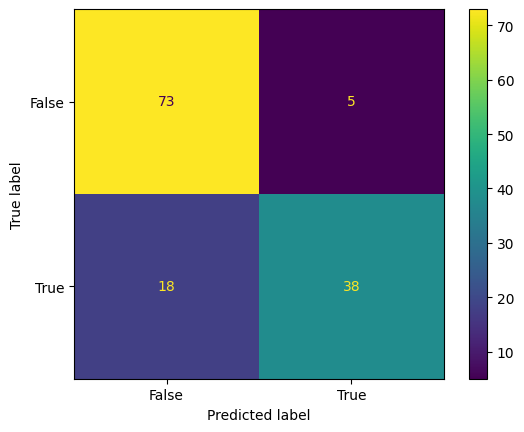

In [25]:
confusion_matrix = metrics.confusion_matrix(model_results_frame['Survived'], model_results_frame['Predicted_Survived'])
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])

cm_display.plot()
plt.show()

In [26]:
metrics.accuracy_score(model_results_frame['Survived'], model_results_frame['Predicted_Survived'])

0.8283582089552238